## Homework B4: Bangladesh Data: Trying out a Latent Mundlak Machine
by Prabhakar Srivastava

In [21]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from graphviz import Digraph as gr
import pytensor.tensor as pt

In [26]:
# Random seed and plotting style
random_seed = sum(map(ord, "Homework B4 Latent Mundlak Machine"))

az.style.use("arviz-doc")

For the purpose of this exercise let us keep the DAG simple: Just Age (A) and Kids (K) <br>
Additionally we will continue to model Kids as an ordered effect <br>
Let use denote the unobserved confound with $G$ which is dashed

DAG: Directed Acylic Graph

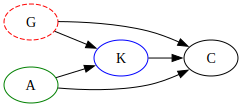

In [6]:
g = gr()
g.attr(rankdir="LR")
g.node("G", color="red", style="dashed")
g.node("A", color="green")
g.node("C", color="black")
g.node("K", color="blue")
g.edge(tail_name="G", head_name="C")
g.edge(tail_name="G", head_name="K")
g.edge(tail_name="A", head_name="C")
g.edge(tail_name="A", head_name="K")
g.edge(tail_name="K", head_name="C")
g

Formula: We continue to keep K as an ordered effect<br>
<center> $C \sim \text{Bernoulli}(p)$ </center>

<center> $p = \text{invlogit}(a_{D[i]} + \beta_A \cdot A + \beta_K \cdot K + \beta_G \cdot G_{D[i]})$ </center>

<center> $G_{D[i]} \sim \gamma_0 + \gamma_1 * \text{Normal}(0, 1)_{D[i]}$ (Unobserved Confound over Districts)</center>

Import Data

In [9]:
filepath_str:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/bangladesh.csv"
df = pd.read_csv(filepath_str, sep=";")

df["district_id"] = df["district"].sub(1)
df["K"] = df["living.children"].sub(1) 


In [17]:
# Coordinates for PyMC Model
NDistrict = df["district"].max()
KMax = len(df["K"].unique())

COORDS = {
    "district": np.arange(NDistrict),
    "kids": np.arange(KMax),
    "obs": np.arange(len(df))
}

PyMC Model

In [42]:
with pm.Model(coords=COORDS) as hm_b04:

    # Data containers
    A = pm.Data("A", df["age.centered"].values, dims="obs")
    D = pm.Data("D", df["district_id"].values, dims="obs")
    C = pm.Data("C", df["use.contraception"].values, dims="obs")
    Kobs = pm.Data("Kobs", df["K"].values, dims="obs")

    # Priors
    # Intercept: vary by District
    α_bar = pm.Normal("α_bar", 0, 1.)
    σ_α = pm.Exponential("σ_α", 1.0)
    z_α = pm.Normal("z_α", 0, 1, dims="district")

    α = α_bar + σ_α * z_α

    # Age effect
    β_age = pm.Normal("β_age", mu=0, sigma=1.)

    # Latent effect
    β_G = pm.Normal("β_G", mu=0, sigma=1.)

    # Ordered effect
    β_K = pm.Normal("β_K", mu=0, sigma=1.)
    δ_ = pm.Dirichlet("δ_", pt.ones(KMax-1))
    δ = pt.concatenate([[0.], pt.cumsum(δ_)])

    # Latent submodel
    γ_0 = pm.Normal("γ_0", 0, 1)
    γ_1 = pm.Normal("γ_1", 0, 1)
    G = pm.Normal("G", 0, 1, dims="district")

    γ = γ_0 + γ_1 * G

    η_ = pm.Dirichlet("η_", pt.ones(KMax)) 
    η = pm.Deterministic("η", pt.cumsum(η_)[:-1] * KMax)
    K = pm.OrderedLogistic("K", eta=γ[D], cutpoints=η, observed=Kobs, dims="obs")

    # Regression
    μ = α[D] + β_age * A + β_K * δ[K] + β_G * G[D]

    p = pm.Deterministic("p", pm.math.invlogit(μ), dims="obs")

    # Likelihood
    likelihood = pm.Bernoulli("likelihood", p, observed=C, dims="obs")

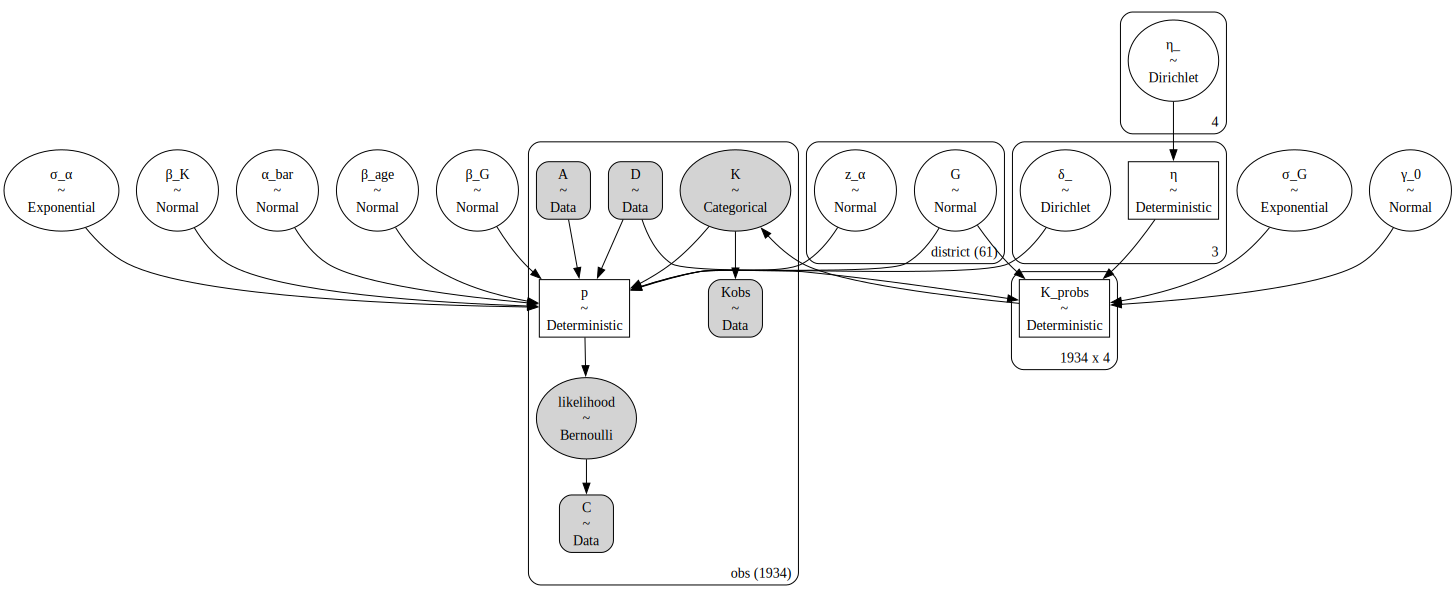

In [36]:
pm.model_to_graphviz(hm_b04)

In [43]:
with hm_b04:
    idata = pm.sample(random_seed=random_seed)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α_bar, σ_α, z_α, β_age, β_G, β_K, δ_, γ_0, γ_1, G, η_]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 104 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [44]:
az.summary(idata, var_names=["~p", "~K_probs"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α_bar,-1.428,0.142,-1.696,-1.165,0.003,0.002,1848.0,2689.0,1.00
z_α[0],-0.436,0.795,-1.786,1.202,0.022,0.017,1406.0,2201.0,1.00
z_α[1],-0.150,0.843,-1.807,1.388,0.014,0.014,3861.0,2736.0,1.00
z_α[2],0.394,0.979,-1.577,2.126,0.016,0.018,3754.0,2630.0,1.00
z_α[3],0.502,0.847,-1.060,2.153,0.017,0.017,2628.0,1474.0,1.00
...,...,...,...,...,...,...,...,...,...
η_[2],0.161,0.009,0.144,0.176,0.000,0.000,4008.0,3374.0,1.00
η_[3],0.508,0.111,0.297,0.653,0.004,0.003,742.0,1264.0,1.01
η[0],0.510,0.444,0.000,1.348,0.015,0.011,648.0,578.0,1.01
η[1],1.322,0.444,0.756,2.150,0.015,0.011,719.0,1061.0,1.01
